In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Set paths
base_dir = r"E:\Coins\New_Dataset_V2"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

# Image size and parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32
EPOCHS = 100

# Data augmentation and rescaling
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data loaders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get number of classes
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")

# Model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_path = "best_model.h5"
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, model_checkpoint]
)

# Plot accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

# Load best model for evaluation
from tensorflow.keras.models import load_model
best_model = load_model(checkpoint_path)

# Evaluate
loss, accuracy = best_model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


ModuleNotFoundError: No module named 'tensorflow'

In [1]:
import os
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import FasterRCNN, FastRCNNPredictor
from torchvision.models.detection import resnet50_fpn_backbone
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Custom Dataset Class (for the coin dataset)
class CoinDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.imgs = list(sorted(os.listdir(os.path.join(root_dir, "train"))))  # Adjust according to your folder structure
        self.classes = ['__background__', 'Philippine One Peso', 'Philippine Five Peso', 'Philippine Ten Peso', 
                        'Japanese One Yen', 'Japanese Five Yen', 'Japanese Ten Yen', 'Japanese Fifty Yen', 
                        'Japanese One Hundred Yen', 'Japanese Five Hundred Yen', 'Korean One Won', 
                        'Korean Ten Won', 'Korean Fifty Won', 'Korean One Hundred Won', 'Korean Five Hundred Won', 
                        'Thai One Baht', 'Thai Five Baht', 'Thai Ten Baht', 'Chinese One Yuan']
    
    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, 'train', self.imgs[idx])
        image = Image.open(img_name).convert("RGB")
        boxes = []  # Collect bounding boxes here
        labels = []  # Collect labels here (You will need to extract annotations from a JSON or text file)
        target = {'boxes': torch.tensor(boxes), 'labels': torch.tensor(labels)}
        if self.transform:
            image = self.transform(image)
        return image, target

# Step 2: Define the Custom Faster-RCNN Architecture
class CustomFasterRCNN(FasterRCNN):
    def __init__(self, backbone, num_classes):
        # Setup the custom backbone (ResNet50) and add the custom layers
        super().__init__(backbone, num_classes)
        
        # Adding custom layers after ResNet backbone
        self.conv1 = nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1)
        self.maxpool1 = nn.MaxPool2d(2)
        self.dropout1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1)
        self.maxpool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 8 * 8, 1024)  # Adjust dimensions based on image size
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, images, targets=None):
        # Pass through the original FasterRCNN network
        x = super().forward(images, targets)
        
        # Custom Convolutional and Fully Connected Layers
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        
        return x

# Step 3: Create the Model with ResNet50 Backbone
def create_model(num_classes):
    # Load a pre-trained ResNet50 backbone
    backbone = resnet50_fpn_backbone(pretrained=True)
    
    # Instantiate the model with the custom architecture
    model = CustomFasterRCNN(backbone, num_classes)
    return model

# Step 4: Set up DataLoader and Transform
transform = transforms.Compose([
    transforms.Resize((800, 800)),
    transforms.ToTensor(),
])

train_data = CoinDataset(root_dir="path/to/dataset", transform=transform)
train_loader = DataLoader(train_data, batch_size=4, shuffle=True)

# Step 5: Training the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 19  # 18 classes + 1 background

# Create the model
model = create_model(num_classes).to(device)

# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Loss function is handled by Faster-RCNN

# Save the best model
best_model_wts = model.state_dict()
best_loss = float('inf')

# Training loop
num_epochs = 20  # Define the number of epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        losses.backward()
        optimizer.step()
        
        running_loss += losses.item()
    
    # Step the scheduler
    lr_scheduler.step()

    # Print and save best model
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")
    if running_loss < best_loss:
        best_loss = running_loss
        best_model_wts = model.state_dict()

# Save the best model
torch.save(best_model_wts, 'best_fasterrcnn_model.pth')

# Step 6: Evaluate the Model (on validation dataset)
model.load_state_dict(torch.load('best_fasterrcnn_model.pth'))
model.eval()

# Create validation dataset and DataLoader
valid_data = CoinDataset(root_dir="path/to/valid_dataset", transform=transform)
valid_loader = DataLoader(valid_data, batch_size=4, shuffle=False)

# Evaluation loop
for images, targets in valid_loader:
    images = [image.to(device) for image in images]
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    with torch.no_grad():
        predictions = model(images)
    # Use predictions for evaluation (e.g., calculate IoU, accuracy)

# Visualization function for predictions
def plot_results(images, predictions):
    fig, ax = plt.subplots(1, len(images), figsize=(15, 15))
    for i, (image, prediction) in enumerate(zip(images, predictions)):
        ax[i].imshow(image.permute(1, 2, 0))
        for box in prediction['boxes']:
            ax[i].add_patch(plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='r', facecolor='none'))
    plt.show()


ImportError: cannot import name 'FastRCNNPredictor' from 'torchvision.models.detection' (C:\Users\silva\anaconda3\Lib\site-packages\torchvision\models\detection\__init__.py)

In [4]:
import torchvision
print(torchvision.__version__)



0.21.0+cu118


In [5]:
import torch
print(torch.__version__)


2.6.0+cu118


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

# Paths
train_dir = "E:/Coins/New_Dataset_V2/train"
val_dir = "E:/Coins/New_Dataset_V2/valid"
save_dir = "E:/Coins/New Class Model RCNN"
os.makedirs(save_dir, exist_ok=True)

# Seed setup
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_classes = 17
batch_size = 64
num_epochs = 500
patience = 15
cutmix_prob = 0.5
label_smoothing = 0.1

# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets and loaders
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# CutMix utility
def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size()[0])
    y_a, y_b = y, y[rand_index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

# Custom EfficientNet model
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model("efficientnet_b2", pretrained=True, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

model = CustomEfficientNet(num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

# Training loop
best_acc = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        if np.random.rand() < cutmix_prob:
            x, y_a, y_b, lam = cutmix_data(x, y)
            outputs = model(x)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        else:
            outputs = model(x)
            loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    scheduler.step()
    train_acc = 100.*correct/total

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    val_acc = 100. * correct / total
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break

# Save last model
torch.save(model.state_dict(), os.path.join(save_dir, "last_model.pth"))


C:\Users\silva\anaconda3\envs\coin_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch [1/500]:   0%|                                                                           | 0/532 [00:17<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

# ==== Paths ====
train_dir = r"E:\Coins\New_Dataset_V2\train"
val_dir = r"E:\Coins\New_Dataset_V2\valid"
save_dir = r"E:\Coins\Retrained_Model"
os.makedirs(save_dir, exist_ok=True)

# ==== Model to resume from ====
resume_path = r"E:\Coins\best_model94.47%.pth"

# ==== Seed ====
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Hyperparameters ====
num_classes = 17
batch_size = 64
num_epochs = 200
patience = 15
cutmix_prob = 0.5
label_smoothing = 0.1

# ==== Transforms ====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Dataset & Loader ====
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# ==== CutMix Utilities ====
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size()[0])
    y_a, y_b = y, y[rand_index]
    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
    return x, y_a, y_b, lam

# ==== Custom EfficientNet Model ====
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model("efficientnet_b2", pretrained=True, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ==== Initialize model ====
model = CustomEfficientNet(num_classes).to(device)

# ==== Load pretrained weights ====
if os.path.exists(resume_path):
    print(f"Loading weights from {resume_path}...")
    model.load_state_dict(torch.load(resume_path, map_location=device))
else:
    print("Resume path not found. Starting fresh training.")

# ==== Loss, Optimizer, Scheduler ====
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

# ==== Training ====
best_acc = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, correct, total = 0, 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        if np.random.rand() < cutmix_prob:
            x, y_a, y_b, lam = cutmix_data(x, y)
            outputs = model(x)
            loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
        else:
            outputs = model(x)
            loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    scheduler.step()
    train_acc = 100.*correct/total

    # ==== Validation ====
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    val_acc = 100. * correct / total
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # ==== Save best ====
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break

# ==== Save last ====
torch.save(model.state_dict(), os.path.join(save_dir, "last_model.pth"))


C:\Users\silva\AppData\Local\Temp\ipykernel_3176\318987818.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev


Per-class accuracy:
Chinese One Yuan Coin: 91.30% (21/23)
Japanese Fifty Yen Coin: 88.89% (32/36)
Japanese Five Hundred Yen Coin: 95.24% (20/21)
Japanese Five Yen Coin: 96.23% (51/53)
Japanese One Hundred Yen Coin: 95.92% (47/49)
Japanese One Yen Coin: 93.62% (44/47)
Japanese Ten Yen Coin: 95.19% (99/104)
Korean Fifty Won Coin: 96.88% (31/32)
Korean Five Hundred Won Coin: 80.00% (24/30)
Korean One Hundred Won Coin: 95.56% (43/45)
Korean Ten Won Coin: 91.11% (41/45)
Philippine Five Peso Coin: 87.23% (41/47)
Philippine One Peso Coin: 87.10% (54/62)
Philippine Ten Peso Coin: 89.47% (34/38)
Thailand Five Baht Coin: 65.45% (36/55)
Thailand One Baht Coin: 86.05% (37/43)
Thailand Ten Baht Coin: 85.29% (29/34)

Classification Report:
                                precision    recall  f1-score   support

         Chinese One Yuan Coin       0.84      0.91      0.88        23
       Japanese Fifty Yen Coin       0.91      0.89      0.90        36
Japanese Five Hundred Yen Coin       0.80     

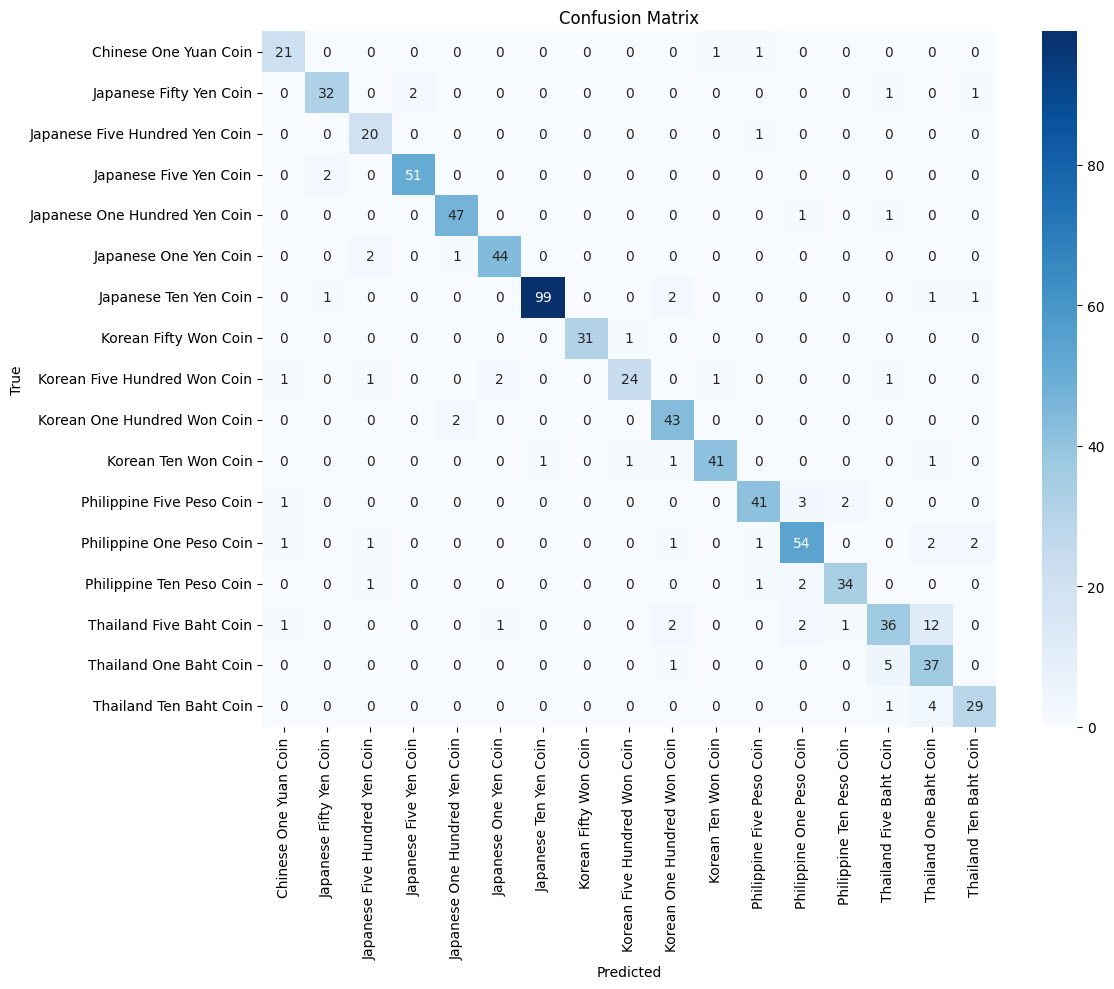

In [5]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==== Paths ====
test_dir = r"E:\Coins\New coins\test"
model_path = r"E:\Coins\Retrained_Model\best_model.pth"

# ==== Hyperparameters ====
num_classes = 17
batch_size = 64

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Test Transform ====
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Dataset & Loader ====
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==== Custom EfficientNet Model ====
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model("efficientnet_b2", pretrained=False, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ==== Load model ====
model = CustomEfficientNet(num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# ==== Evaluation ====
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# ==== Per-class accuracy ====
class_names = test_dataset.classes
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

print("\nPer-class accuracy:")
for idx, class_name in enumerate(class_names):
    class_correct = np.sum((all_labels == idx) & (all_preds == idx))
    class_total = np.sum(all_labels == idx)
    acc = 100 * class_correct / class_total if class_total > 0 else 0
    print(f"{class_name}: {acc:.2f}% ({class_correct}/{class_total})")

# ==== Classification report ====
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ==== Confusion Matrix ====
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [7]:
import torch
import torch.nn as nn
from torchvision import transforms
from timm import create_model
from PIL import Image
import os

# ==== Paths ====
model_path = r"E:\Coins\Retrained_Model\best_model.pth"
image_path = r"E:\Downloads\111222.png"
test_dir = r"E:\Coins\New coins\test"  # Needed for class names

# ==== Device ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Image Transform ====
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==== Custom EfficientNet Model ====
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model("efficientnet_b2", pretrained=False, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ==== Load class names from dataset folder ====
from torchvision import datasets
dataset = datasets.ImageFolder(test_dir)
class_names = dataset.classes
num_classes = len(class_names)

# ==== Load model ====
model = CustomEfficientNet(num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# ==== Load and preprocess image ====
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

# ==== Inference ====
with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)

# ==== Output result ====
predicted_label = class_names[predicted_class.item()]
confidence_score = confidence.item() * 100

print(f"Predicted Label: {predicted_label}")
print(f"Confidence Score: {confidence_score:.2f}%")


C:\Users\silva\AppData\Local\Temp\ipykernel_3176\4208375157.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de

Predicted Label: Philippine Ten Peso Coin
Confidence Score: 51.17%


In [ ]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm
import albumentations as A

# === CONFIG ===
input_folder = "E:/Coins/New_Dataset_V2/train/Korean Five Won Coin"       # Your 120 coin images
output_folder = "E:/Coins/New_Dataset_V2/five"  # Folder to save new images
target_images = 3000                # Total images you want

os.makedirs(output_folder, exist_ok=True)

# === AUGMENTATION PIPELINE ===
transform = A.Compose([
    A.Rotate(limit=360, border_mode=cv2.BORDER_CONSTANT, p=0.8),
    A.RandomScale(scale_limit=0.4, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.7),
    A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    A.RandomCrop(height=400, width=400, p=0.5),
    A.Resize(height=640, width=640)
])

# === LOAD IMAGES ===
image_files = [
    f for f in os.listdir(input_folder)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
]

count = 0

print("Generating augmented images...")

while count < target_images:
    for img_file in image_files:
        if count >= target_images:
            break

        img_path = os.path.join(input_folder, img_file)
        image = cv2.imread(img_path)

        if image is None:
            continue

        augmented = transform(image=image)
        aug_img = augmented["image"]

        save_name = f"aug_{count}.jpg"
        cv2.imwrite(os.path.join(output_folder, save_name), aug_img)

        count += 1

print(f"Done! Generated {count} images in '{output_folder}' folder.")

In [7]:
import sys
!{sys.executable} -m pip install albumentations opencv-python tqdm

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\silva\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

# ===============================
# Paths
# ===============================
train_dir = r"E:\Coins\New_Dataset_V2\train"
val_dir   = r"E:\Coins\New_Dataset_V2\valid"
save_dir  = r"E:\Coins\Coin Classification.v8i.yolov8"
resume_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_old.pth"

os.makedirs(save_dir, exist_ok=True)

# ===============================
# Seed
# ===============================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# Dataset
# ===============================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

num_classes = len(train_dataset.classes)  # Automatically detects 19

print("Classes:", train_dataset.classes)
print("Total classes:", num_classes)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

# ===============================
# Model
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

model = CustomEfficientNet(num_classes).to(device)

# ===============================
# Load Old Weights (Except Final Layer)
# ===============================
if os.path.exists(resume_path):
    print("Loading previous weights...")
    old_state = torch.load(resume_path, map_location=device)
    model_state = model.state_dict()

    # Remove last layer weights (size mismatch)
    filtered_state = {
        k: v for k, v in old_state.items()
        if k in model_state and v.size() == model_state[k].size()
    }

    model_state.update(filtered_state)
    model.load_state_dict(model_state)
    print("Backbone weights loaded successfully.")
else:
    print("Previous model not found. Training from scratch.")

# ===============================
# Training Setup
# ===============================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # smaller LR for fine-tuning

num_epochs = 150
patience = 15

cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

# ===============================
# Training Loop
# ===============================
best_acc = 0
epochs_no_improve = 0

for epoch in range(num_epochs):

    model.train()
    correct, total = 0, 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

    for x, y in loop:

        x, y = x.to(device), y.to(device)

        outputs = model(x)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()

        loop.set_postfix(acc=100. * correct / total)

    scheduler.step()
    train_acc = 100. * correct / total

    # ===============================
    # Validation
    # ===============================
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    val_acc = 100. * correct / total
    print(f"Validation Accuracy: {val_acc:.2f}%")

    # ===============================
    # Save Best
    # ===============================
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(save_dir, "best_model_19classes.pth"))
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

# ===============================
# Save Final
# ===============================
torch.save(model.state_dict(), os.path.join(save_dir, "last_model_19classes.pth"))

print("Training completed.")

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ===============================
# Model Definition
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ===============================
# Main Execution Block (Crucial for Windows)
# ===============================
if __name__ == '__main__':
    # ===============================
    # Paths & Setup
    # ===============================
    train_dir = r"E:\Coins\New_Dataset_V2\train"
    val_dir   = r"E:\Coins\New_Dataset_V2\valid"
    save_dir  = r"E:\Coins\Coin Classification.v8i.yolov8"
    resume_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_old.pth"

    os.makedirs(save_dir, exist_ok=True)
    set_seed()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device.type == "cuda":
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # ===============================
    # Dataset & Transforms
    # ===============================
    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

    num_classes = len(train_dataset.classes)
    print("Detected classes:", train_dataset.classes)
    print("Total classes:", num_classes)

    # ===============================
    # DataLoaders
    # ===============================
    train_loader = DataLoader(
        train_dataset, batch_size=64, shuffle=True,
        num_workers=8, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False,
        num_workers=4, pin_memory=True
    )

    # ===============================
    # Initialize Model & Load Weights
    # ===============================
    model = CustomEfficientNet(num_classes).to(device)

    if os.path.exists(resume_path):
        print("Loading previous weights...")
        old_state = torch.load(resume_path, map_location=device)
        model_state = model.state_dict()
        # Filter out weights that don't match (like your new 19-class final layer)
        filtered_state = {
            k: v for k, v in old_state.items()
            if k in model_state and v.size() == model_state[k].size()
        }
        model_state.update(filtered_state)
        model.load_state_dict(model_state)
        print("Backbone weights loaded successfully.")
    else:
        print("Previous model not found. Training from scratch.")

    # ===============================
    # Training Setup
    # ===============================
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    num_epochs = 150
    patience = 15

    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

    # ===============================
    # Training Loop
    # ===============================
    best_acc = 0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        correct, total = 0, 0

        # Note: mininterval is removed so it updates instantly. 
        # Added leave=False so the bar disappears after the epoch to keep the terminal clean.
        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

        for x, y in train_loop:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            outputs = model(x)
            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics calculation
            train_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
            # Live feedback per batch
            current_acc = 100. * correct / total
            train_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")

        scheduler.step()
        
        epoch_train_loss = train_loss / total
        epoch_train_acc = 100. * correct / total

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        
        # Added a progress bar for validation too
        val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Valid", leave=False)

        with torch.no_grad():
            for x, y in val_loop:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
                
                current_val_acc = 100. * correct / total
                val_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_val_acc:.2f}%")

        epoch_val_loss = val_loss / total
        epoch_val_acc = 100. * correct / total

        # Clear, permanent summary printed at the end of each epoch
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

        # ===============================
        # Save Best Model
        # ===============================
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_19classes.pth"))
            epochs_no_improve = 0
            print(f" --> Best model saved! (Acc: {best_acc:.2f}%)")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    # ===============================
    # Save Last Model
    # ===============================
    torch.save(model.state_dict(), os.path.join(save_dir, "last_model_19classes.pth"))
    print("Training completed.")

In [3]:
!pip install timm

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 49.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/596.3 kB ? eta -:--:--
   --------------------------------------- 596.3/596.3 kB 10.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ---------------------------------------- 3.6/3.6 MB 71.9 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm.notebook import tqdm  # Changed to the Jupyter-friendly version
import numpy as np
import random
from warmup_scheduler import GradualWarmupScheduler

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# ===============================
# Model Definition
# ===============================
class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

# ===============================
# Main Execution Block
# ===============================
if __name__ == '__main__':
    # ===============================
    # Paths & Setup
    # ===============================
    train_dir = r"E:\Coins\New_Dataset_V2\train"
    val_dir   = r"E:\Coins\New_Dataset_V2\valid"
    save_dir  = r"E:\Coins\Coin Classification.v8i.yolov8"
    resume_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_old.pth"

    os.makedirs(save_dir, exist_ok=True)
    set_seed()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device.type == "cuda":
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # ===============================
    # Dataset & Transforms
    # ===============================
    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

    num_classes = len(train_dataset.classes)
    print("Detected classes:", train_dataset.classes)
    print("Total classes:", num_classes)

    # ===============================
    # DataLoaders (Fixed for Jupyter)
    # ===============================
    train_loader = DataLoader(
        train_dataset, batch_size=64, shuffle=True,
        num_workers=0, pin_memory=True  # 0 prevents Jupyter/Windows deadlock
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False,
        num_workers=0, pin_memory=True  # 0 prevents Jupyter/Windows deadlock
    )

    # ===============================
    # Initialize Model & Load Weights
    # ===============================
    model = CustomEfficientNet(num_classes).to(device)

    if os.path.exists(resume_path):
        print("Loading previous weights...")
        old_state = torch.load(resume_path, map_location=device)
        model_state = model.state_dict()
        
        # Filter out weights that don't match the new 19-class architecture
        filtered_state = {
            k: v for k, v in old_state.items()
            if k in model_state and v.size() == model_state[k].size()
        }
        model_state.update(filtered_state)
        model.load_state_dict(model_state)
        print("Backbone weights loaded successfully.")
    else:
        print("Previous model not found. Training from scratch.")

    # ===============================
    # Training Setup
    # ===============================
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    num_epochs = 150
    patience = 15

    cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scheduler = GradualWarmupScheduler(optimizer, multiplier=1, total_epoch=5, after_scheduler=cosine_scheduler)

    # ===============================
    # Training Loop
    # ===============================
    best_acc = 0
    epochs_no_improve = 0

    print("\nStarting Training...")
    for epoch in range(num_epochs):
        
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0.0
        correct, total = 0, 0

        # leave=False keeps the notebook output clean by removing the bar after completion
        train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

        for x, y in train_loop:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            
            outputs = model(x)
            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics calculation
            train_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
            
            # Live feedback per batch
            current_acc = 100. * correct / total
            train_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")

        scheduler.step()
        
        epoch_train_loss = train_loss / total
        epoch_train_acc = 100. * correct / total

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        
        val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Valid", leave=False)

        with torch.no_grad():
            for x, y in val_loop:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                outputs = model(x)
                loss = criterion(outputs, y)

                val_loss += loss.item() * x.size(0)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
                
                # Live feedback per batch for validation
                current_val_acc = 100. * correct / total
                val_loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_val_acc:.2f}%")

        epoch_val_loss = val_loss / total
        epoch_val_acc = 100. * correct / total

        # Clear, permanent summary printed at the end of each epoch
        print(f"Epoch {epoch+1:03d}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

        # ===============================
        # Save Best Model & Early Stopping
        # ===============================
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_19classes.pth"))
            epochs_no_improve = 0
            print(f" --> Best model saved! (Acc: {best_acc:.2f}%)")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break

    # ===============================
    # Save Last Model
    # ===============================
    torch.save(model.state_dict(), os.path.join(save_dir, "last_model_19classes.pth"))
    print("\nTraining completely finished.")